##### Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print(usage.isna().mean()) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**`Users:`** En este dataset se encontraron dos columnas con valores faltantes, la columna **City** presenta **469** registros nulos, equivalentes al **11,72%**, mientras la columna **Churn Date** tiene **3534** valores faltantes, correspondientes al **88,35%** de los registros.Considerando el objetivo del análisis, la variable *Churn Date* puede excluirse del proceso de preparación de datos, ya que no aporta información relevante para las preguntas de negocio. Por otro lado, la variable *City* debe conservarse y validar la imputación de valores o análizar su patrón de ausencia.

**`Usage:`** Se identificaron tres columnas con valores faltante. La columna **Date** presenta **50** registros nulos, equivalentes al **0,125%**. Dado que este porcentaje es minimo y no afecta significativamente los resultados esperados del análisis estos registros pueden ser ignorados. Por otra parte, la columna **Duration** tiene **22076** valores faltantes, correspondientes a **55,19%** de los datos, mientras que la columna **Length** registra **17896** datos nulos correspondientes al **44,74%** de los datos. Debido a que estas dos últimas variables son clave para responder las preguntas de negocio planteadas, se les debe aplicar imputación para preservar la mayor catidad de información posible y garantizar la calidad de la calidad de los resultados.  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no presenta inconsistencias, no hay valores faltantes, la media coincide exactamente con la mediana (**11999.50**) y puede usarse unicamente como identificador único de los registros.
- La columna `age` tiene al menos un sentinel evidenciado con un -999 como valor mínimo. Esto distorsiona la media (**33.77**) y la desviación estándar (**123.23**) con un valor imposible para la variable de edad y por tanto en este caso la mediana es más confiable que la media.

In [14]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no presentan valores faltantes y los registros están completos. La columna `id` es un identificador único secuencial y la columna `user_id` muestra que existen aproximadamente 4000 usuarios únicos. 
- Las columnas `duration` y `length` presentan un número significativo de valores faltantes. En la variable `duration` se observa que la media es mayor que la mediana, indicando que existen registros con duraciones muy elevadas. Mientras que en la variable `length` la media y la mediana son muy similares, lo que indica una distribución normal de los datos, sin embargo, existen valores extremos muy pronunciados.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595



- La columna `city` contiene valores faltantes y registra información de 7 ciudades diferentes, la distribución de frecuencias muestra mayor concentración de usuarios en **Bogotá** que acumula **808 registros**. 
- La columna `plan` no tiene registros nulos. Se identifican dos tipos de planes, siendo el **plan Básico** el más utilizado con **2595 registros**, lo que evidencia una mayor adopción de este plan por los usuarios.


In [16]:
# explorar columna categórica de usage
usage[['type']].describe() # completa el código

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` no tiene valores nulos. Se identifican dos tipos de usos siendo el más frecuente **text** con 22092 registros.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

El conjunto de datos del dataset `users` contiene 4000 registros y presenta un problema de calidad en la variable **age**, con al menos un valor inválido (-999). Este dato distorsiona tanto la media como la desviación estándar y por tanto debe tratarse antes de realizar análisis posteriores, por lo cual, se sugiere **reemplazar este valor por la mediana**.

El conjunto de datos del dataset `usage` contiene 40000 registros asociados a aproximadamente 4000 usuarios. Las variables **duration** y **length** presentan una alta proporción de valores faltantes (**55,19%** y **44,74%** respectivamente), adicionalmente ambas variables muestran sesgo hacia la derecha con valores máximos atípicos, especialmente **length**, cuyo valor máximo (**1490**) se encuentra muy alejado del comportamiento típico. Por esto, se debe investigar el patrón de los valores faltantes y analizar la relación entre ambas variables antes de imputar.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce", utc = True) # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce", utc = True) # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, cuenta con un total 4000 registro desde el año 2022 hasta el año 2026. Sin embargo, para efectos de este análisis trabajaremos con los datos registrados hasta el 2024, es decir un **total de 3960 registros**.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, para el dataset **usage** únicamente se encuentran registros del año 2024. Por lo cual, podemos concluir que el análisis únicamente se realizará para este año con los otros datasets. 

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En la columna `reg_date` del dataset **users** muestra que no existen registros para el año **2025** y se identifican **40 registros para el 2026** lo cual corresponde a un registro en una fecha futura. Dado que estos datos representan una proporción muy reducida y corresponden a un periodo posterior, se consideran irrelevantes para el alcance del presente análisis y por tanto deberán marcarse como un valor inválido.

Por otra parte, la columna `date` del dataset **usage** contiene registros exclusivamente del año **2024**, lo que indica que es el único periodo con información completa de este dataset. En consecuencia, para garantizar la compatibilidad de los resultados, el análisis se realizará únicamente sobre los datos correspondientes al año **2024**.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].head(5)

0    Medellín
1        <NA>
2        CDMX
3      Bogotá
4         GDL
Name: city, dtype: object

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnóstico de nulos en `duration` y `length`

Los resultados muestran que el **99,93%** de los registros de tipo **text** presentan **valores nulos** en `duration`, mientras que los registros de tipo **call no presentan datos faltantes** en esta variable. De manera análoga, el **99,93%** de los registros de tipo **call** tienen **valores nulos** en `length`, mientras que los registros de tipo **text** cuentan con información completa para esta variable.

Este comportamiento indica que la ausencia de datos depende de una variable observada (type), por lo que los valores faltantes pueden clasificarse como **MAR** (Missing At Random). Además, desde la lógica del negocio, dichos nulos son esperados, ya que la duración solo aplica a las llamadas y la longitud únicamente a los mensajes de texto.

En consecuencia, los valores faltantes no serán imputados ni eliminados, ya que representan una característica propia del negocio y no una deficiencia en su calidad. Para análisis posteriores, cada variable será evaluada únicamente dentro del tipo de registro para el cual resulta aplicable.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 5.1 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"is_text":"sum","is_call":"sum", "duration": "sum"} ).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on = 'user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
print(user_profile[['plan']].value_counts(normalize=True))

plan   
Basico     0.64875
Premium    0.35125
dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

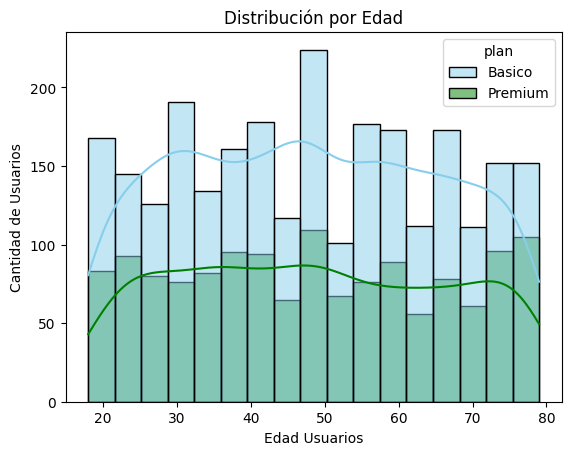

In [31]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue= 'plan', palette=['skyblue','green'], kde = True)
plt.title('Distribución por Edad')
plt.xlabel('Edad Usuarios')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución normal, el uso de ambos planes se mantiene relativamente estable a lo largo de todas las edades, desde los 18 hasta cerca de los 80 años. No se observa un sesgo evidente de que los jóvenes prefieran un plan y los adultos mayores otro.
- Se observa que el volumen de usuarios en en Plan Básico es significativamente mayor al Plan Premium. Esto sugiere que la edad no es una variable que determine un upgrade de plan.
- Se evidencia un pico específico en el consumo de ambos planes en el rango de los 45 a los 50 años.

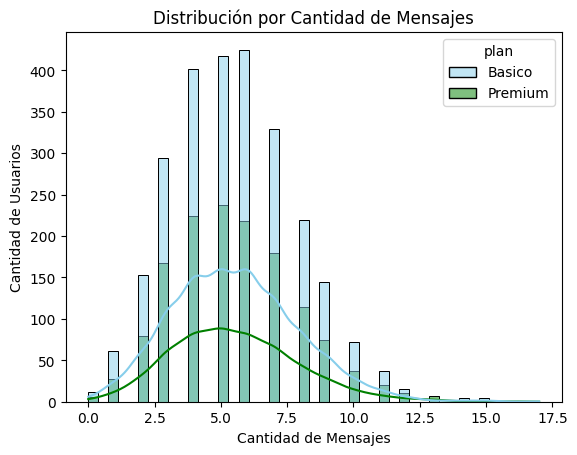

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue= 'plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución por Cantidad de Mensajes')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- El hábito de consumo es idéntico para ambos planes, el consumo está concentrado en un promedio de 4 a 6 mensajes. La única diferencia real entre el plan Básico y Premium es la escala de volumen de usuarios.
- La gran mayoría de los usuarios envía menos de 10 mensajes.
- El Plan Premium no concentra a los usuarios que envían más mensajes, pues se evidencia que la cola hacia la derecha cae igual para ambos planes.

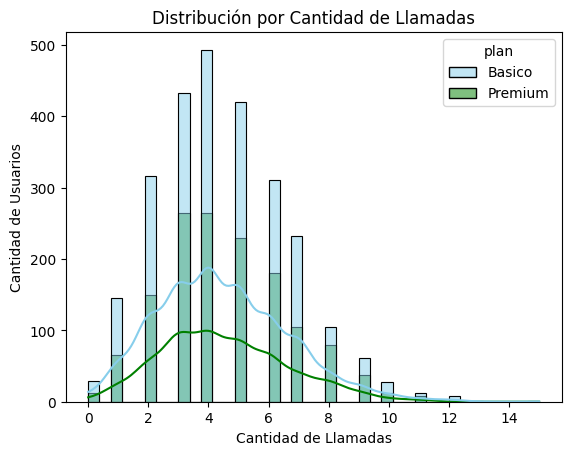

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue= 'plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución por Cantidad de Llamadas')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- En este gráfico se evidencia una Distribución sesgada a la derecha, con pocos usuarios con  más de 10 llamadas  que empujan la media hacia la derecha.
- Para el Plan Premium, el pico de suarios se estabiliza de manera muy clara entre las 3 y 4 llamadas. En el Plan Básico, el pico es más alto justo en las 4 llamadas. Pasando las 7 u 8 llamadas, la cantidad de usuarios decae drásticamente en ambos segmentos. 
- Se observa que hay mayor dispersión en el Plan Básico, lo que indica que la base de llamadas telefónicas depende de los usuarios de este plan. 

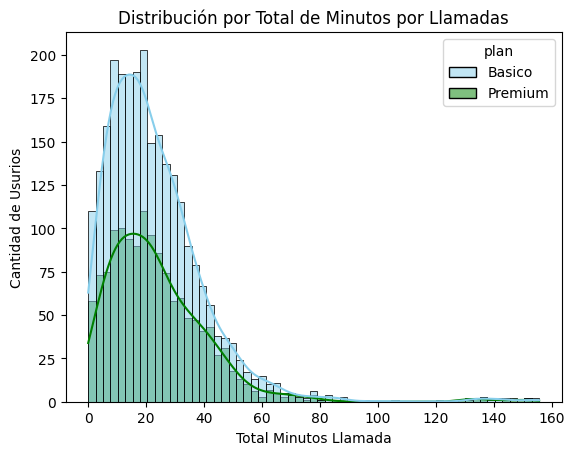

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue= 'plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución por Total de Minutos por Llamadas')
plt.xlabel('Total Minutos Llamada')
plt.ylabel('Cantidad de Usurios')
plt.show()

💡Insights: 
- Acá se observa un sesgo a la derecha muy pronunciado para ambos planes, evidenciando una mayor concentración en llamadas cortas, el grueso de los usuarios de ambos planes habla un total acumulado de entre 10 y 30 minutos.
- La curva principal cae a casi cero al llegar a los 60 min de consumo de voz. Las llamadas de larga duración son una anomalía en la base de clientes.
- Hay un repunte de usuarios en la extrema derecha del gráfico (entre 130 y 160 minutos). Aunque son pocos usuarios, están consumiendo una cantidad superior de minutos muy superior al promedio.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráficos, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

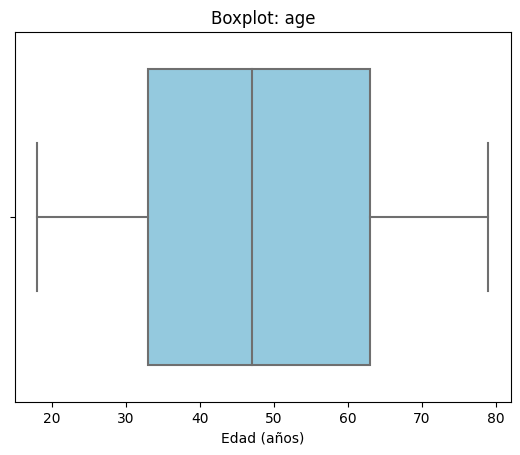

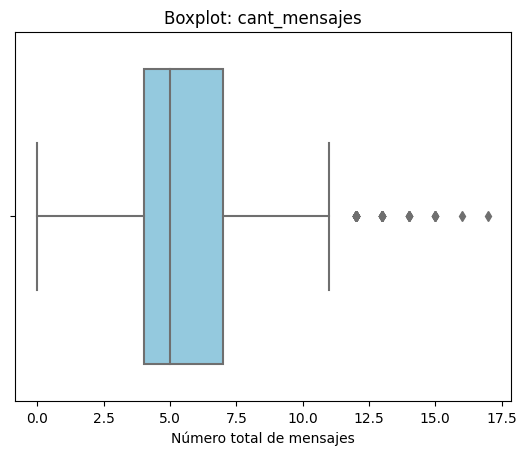

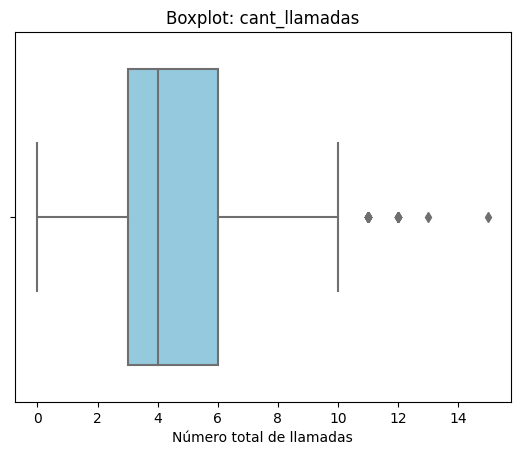

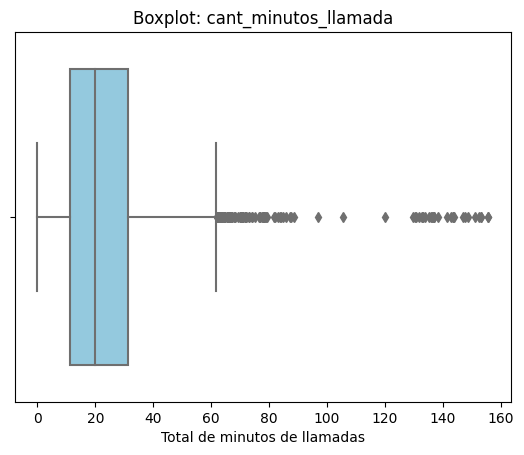

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
etiquetas = {'age': 'Edad (años)', 'cant_mensajes': 'Número total de mensajes', 'cant_llamadas': 'Número total de llamadas', 'cant_minutos_llamada': 'Total de minutos de llamadas'}

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color= 'skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(etiquetas[col])
    plt.show()
    

💡Insights: 
- **Age:** No presenta outliers. Los bigotes Brcan todo el rango de datos. La distribución es simétrica y el 50% de los usuarios se encuentra concentrado entre los 33 y 63 años. Esto indica que la base de datos es homogénea y no depende exclusivamente de un nicho joven o adulto mayor.
- **cant_mensajes:** Si presenta outliers. Hay valores atípicos a partir de los 12 mensajes y un grupo de usuarios rompe el comportamiento común llegando a enviar hasta 17 mensajes. El 75% de los usuarios envía 7 mensajes o menos y la **mediana** se sitúa justo en los **5 mensajes**.
- **cant_llamadas:** Si presenta outliers. Se observan puntos atípicos aislados a la derecha, la caja está fuertemente comprimida entre las 3 y 6 llamadas, teniendo su **mediana en 4 llamadas**.
- **cant_minutos_llamada:** Presenta varios outliers. Es el gráfico con mayor dispersión y volumen de valores atípicos extendiéndose desde los 62 hasta los 160 minutos, mientras que el 50% de la población consume entre 11 y 31 minutos, con una **mediana en 20 minutos**.

In [44]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    Upper = Q3 + 1.5 * IQR
    print(f"IQR {col}: {IQR}")
    print(f"Upper {col}: {Upper}")

IQR cant_mensajes: 3.0
Upper cant_mensajes: 11.5
IQR cant_llamadas: 3.0
Upper cant_llamadas: 10.5
IQR cant_minutos_llamada: 20.295
Upper cant_minutos_llamada: 61.8575


In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no  
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes:** mantener o no outliers, porqué?
El límite estadístico superior se calculó en **11.5** mensajes, mientras que el valor máximo registrado en la base de datos es de 17.0 mensajes. La diferencia entre estos dos es de **5.5** mensajes, por lo cual no es un error de registro sino una variación natural del consumo. Por lo tanto, la decisión es **mantener** los outliers.
- **cant_llamadas:** mantener o no outliers, porqué?
El límite superior por IQR es **10.5** llamadas, sin embargo, vemos clientes que realizan hasta **15** llamadas en el periodo. Al igual que los mensajes, el desfase es pequeño, la mediana es de 4 llamadas y el percentil 75 es de 6, por lo cual, llegar a 15 llamadas es perfectamente factible y no representa un comportamiento fraudulento ni error en la captura de datos, son parte de los clientes frecuentes. Por lo anterior, la decisión es **mantener** los outliers. 
- **cant_minutos_llamada:** mantener o no outliers, porqué?
Esta es la variable crítica. El límite estadístico es 61.86 minutos, pero el valor máximo se dispara hasta los 155.69 minutos, es decir, que el máximo real es casi 2.5 veces superior. Se recomienda no eliminarlos sino **etiquetar como un segmento especial de Alto Valor** e implementar estrategias de upselling.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
def grupo_uso(row):
    if (row['cant_llamadas'] < 5) & (row['cant_mensajes'] < 5):
        return 'Bajo uso'
    elif (row['cant_llamadas'] < 10) & (row['cant_mensajes'] < 10):
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile["grupo_uso"] = user_profile.apply(grupo_uso, axis=1)      

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
def grupo_edad(row):
    if (row['age'] < 30):
        return 'Joven'
    elif (row['age'] < 60):
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile["grupo_edad"] = user_profile.apply(grupo_edad, axis=1)  

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

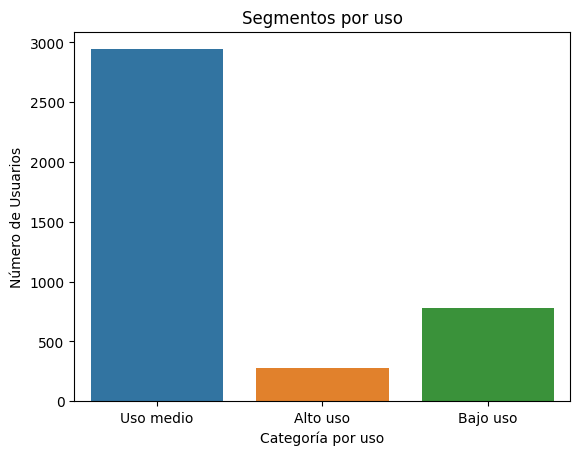

In [45]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title(f'Segmentos por uso')
plt.xlabel('Categoría por uso')
plt.ylabel('Número de Usuarios')
plt.show()

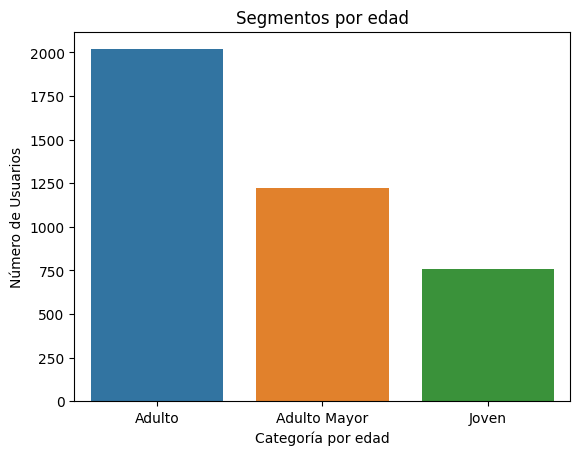

In [43]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title(f'Segmentos por edad')
plt.xlabel('Categoría por edad')
plt.ylabel('Número de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

***1. Valores faltantes en `city` (users_latam):***
- Se encontraron **469 valores faltantes**, equivalentes al **11,72%** de los registros.
- Debido a la relevancia de esta variable para futuras segmentaciones geográficas, se decidió conservarla y evaluar estrategias de imputación cuando sea necesario.
    
***2. Valor inválido en `age` (users_latam):***

Se identificó al menos un registro con el valor **-999**, utilizado como sentinel para representar información desconocida. Debido a que este valor afectaba la media y la desviación estándar de la variable, fue tratado como dato faltante y se reemplazó por la mediana.
    
***3. Fechas futuras en `reg_date` (users_latam):***
- Se encontraron **40 registros correspondientes al año 2026** (1% de los usuarios), mientras que no existían registros para 2025.
- Debido a que el análisis se centra en información consolidada hasta 2024, estos registros fueron excluidos del análisis.

***4. Valores faltantes en `duration` y `length` (usage):***
- `duration` presentaba **22.076 valores faltantes (55,19%)**.
- `length`presentaba **17.896 valores faltantes (44,74%)**.
- El análisis demostró que estos faltantes dependen directamente de la variable `type`, ya que las llamadas registran duración pero no longitud, mientras que los mensajes de texto registran longitud pero no duración. Por esta razón, los valores faltantes se clasificaron como **faltantes estructurales (MAR)** y se mantuvieron sin imputar pues corresponden al comportamiento natural del negocio.

**5. Tipo de datos erróneos** 

Las columnas `reg_date` en users y `date` en usage, estaban formateadas como *object*, por lo cual, se estandarizaron a tipo fecha para poder realizar el análisis para el año 2024.
    
🔍 **Segmentos por Edad** 

Los clientes se clasificaron en tres segmentos:

***1. Jóvenes (< 30 años)***
- Representan el segmento más orientado al uso de mensajería.
-  Tienden a realizar menos llamadas y muestran un comportamiento digital más intensivo.

***2. Adultos (30 – 59 años)***
- Constituyen el grupo predominante de la base de clientes.
- Presentan un uso equilibrado entre llamadas y mensajes.
- Son el segmento más estable y representativo del negocio.

***3. Adultos Mayores (≥ 60 años)***
- Registran menores niveles de actividad general.
- Su comportamiento se concentra principalmente en el uso tradicional de llamadas.
- Podrían requerir planes más simples y enfocados en comunicación básica.

📊 **Segmentos por Nivel de Uso**

***Usuarios de Bajo Uso***
- Consumen pocas llamadas y pocos mensajes.
- Generan menor ingreso potencial por consumo adicional.
- Son candidatos para planes económicos o paquetes simplificados.
  
***Usuarios de Uso Medio***
- Representan el comportamiento más equilibrado y estable.
- Utilizan regularmente los servicios incluidos en sus planes.
- Constituyen la base principal de clientes de ConnectaTel.
  
***Usuarios de Alto Uso***
- Son los clientes más valiosos desde el punto de vista comercial.
- Consumen una mayor cantidad de llamadas y mensajes.
- Tienen mayor probabilidad de generar ingresos adicionales por excedentes o contratación de planes superiores.

**Outliers**

Se identificaron usuarios con niveles de consumo superiores al comportamiento típico de la población:
- En **llamadas**, se encontraron registros por encima del límite estadístico definido mediante IQR.
- En **mensajes**, se observaron usuarios con consumos significativamente superiores al promedio.

Sin embargo, estos valores no fueron considerados errores de captura, ya que se mantienen dentro de rangos admisibles para usuarios intensivos. Por lo tanto, se conservaron en el análisis.

➡️ Esto sugiere que ...

Los resultados muestran que los clientes de ConnectaTel no tienen un comportamiento homogéneo. Existen diferencias claras según la edad y el nivel de uso, lo que evidencia oportunidades para personalizar la oferta comercial.

Asimismo, la presencia de usuarios de consumo intensivo indica que algunos clientes podrían estar alcanzando los límites de sus planes actuales, mientras que otros presentan un consumo muy bajo y podrían estar pagando por servicios que no utilizan completamente.

La predominancia del **Plan Básico (64,9%)** sugiere que una parte importante de los usuarios busca opciones económicas, aunque existe un segmento relevante con patrones de consumo que justificarían ofertas más robustas.

💡 **Recomendaciones**
- Diseñar planes diferenciados por perfil de uso, planes básicos para usuarios de bajo consumo y planes premium con mayores beneficios para usuarios con mayor consumo.
- Implementar estrategias de upselling a los usuarios de alto consumo dentro de los planes básicos y ofrecer cambio a planes premium.
- Crear ofertas al segmento *Jóvenes* incrementando los beneficios asociados a mensajería y servicio digitales.
- Desarrollar planes simplificados para adultos mayores, priorizando minutos incluidos y facilidad de uso.
- Los clientes con mayor consumo representan una oportunidad para desarrollar productos premium y programas de fidelización

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`